# 🧠 Entrenamiento de la Red Neuronal (Backpropagation)
En esta notebook tomamos los patrones numéricos extraídos previamente (varianza, entropía, ruido) y entrenamos un Perceptrón Multicapa para clasificar las imágenes en `REAL` (0) o `FAKE/IA` (1).

In [2]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Configuramos el estilo de los gráficos
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
# 1. Cargar los CSV generados por el script de preprocesamiento
print("Cargando datasets...")
train_df = pd.read_csv('../data/patrones_train.csv')
test_df = pd.read_csv('../data/patrones_test.csv')

# 2. Separar características (X) y etiquetas (y)
X_train = train_df.drop('Target', axis=1)
y_train = train_df['Target']

X_test = test_df.drop('Target', axis=1)
y_test = test_df['Target']

# 3. Escalar los datos (Fundamental para Backpropagation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Patrones de entrenamiento: {X_train.shape[0]}")
print(f"Patrones de validación: {X_test.shape[0]}")

Cargando datasets...
Patrones de entrenamiento: 100000
Patrones de validación: 20000


In [4]:
# 4. Configurar el Perceptrón Multicapa
# Usamos 2 capas ocultas: una de 16 neuronas y otra de 8.
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8), 
    activation='relu',          # Función de activación no lineal
    solver='adam',              # Optimizador del gradiente
    max_iter=500,               # Épocas máximas
    random_state=42,            # Semilla para que los resultados sean reproducibles
    early_stopping=True,        # Detiene el entrenamiento si deja de mejorar
    verbose=True                # Muestra el progreso época por época
)

print("Iniciando entrenamiento por Backpropagation...")
mlp.fit(X_train_scaled, y_train)
print("¡Entrenamiento finalizado!")

Iniciando entrenamiento por Backpropagation...
Iteration 1, loss = 0.56831710
Validation score: 0.750300
Iteration 2, loss = 0.48131580
Validation score: 0.769900
Iteration 3, loss = 0.45418401
Validation score: 0.786600
Iteration 4, loss = 0.43610725
Validation score: 0.792800
Iteration 5, loss = 0.42676421
Validation score: 0.798700
Iteration 6, loss = 0.42178868
Validation score: 0.800300
Iteration 7, loss = 0.41787156
Validation score: 0.804600
Iteration 8, loss = 0.41489313
Validation score: 0.805700
Iteration 9, loss = 0.41232742
Validation score: 0.809400
Iteration 10, loss = 0.41029957
Validation score: 0.810400
Iteration 11, loss = 0.40884510
Validation score: 0.810100
Iteration 12, loss = 0.40724853
Validation score: 0.812700
Iteration 13, loss = 0.40640100
Validation score: 0.811400
Iteration 14, loss = 0.40580574
Validation score: 0.812400
Iteration 15, loss = 0.40529639
Validation score: 0.814300
Iteration 16, loss = 0.40440338
Validation score: 0.815400
Iteration 17, loss

In [5]:
# 5. Predicción sobre el set de prueba
y_pred = mlp.predict(X_test_scaled)

# 6. Mostrar métricas
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy) del modelo: {exactitud * 100:.2f}%\n")

print("Reporte detallado de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'IA/Fake (1)']))

Exactitud (Accuracy) del modelo: 81.52%

Reporte detallado de Clasificación:
              precision    recall  f1-score   support

    Real (0)       0.81      0.83      0.82     10000
 IA/Fake (1)       0.82      0.80      0.81     10000

    accuracy                           0.82     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.82      0.82      0.82     20000



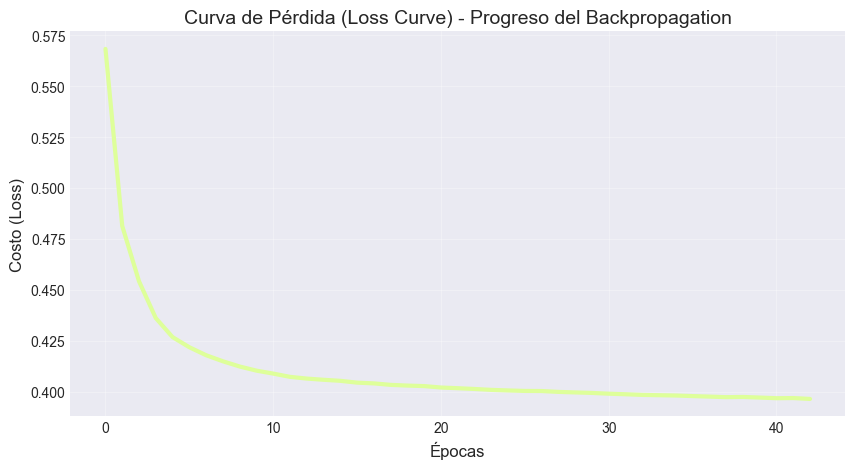

In [6]:
# Visualización del Aprendizaje (Loss Curve) ---
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, color='#deff9a', lw=3)
plt.title('Curva de Pérdida (Loss Curve) - Progreso del Backpropagation', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Costo (Loss)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

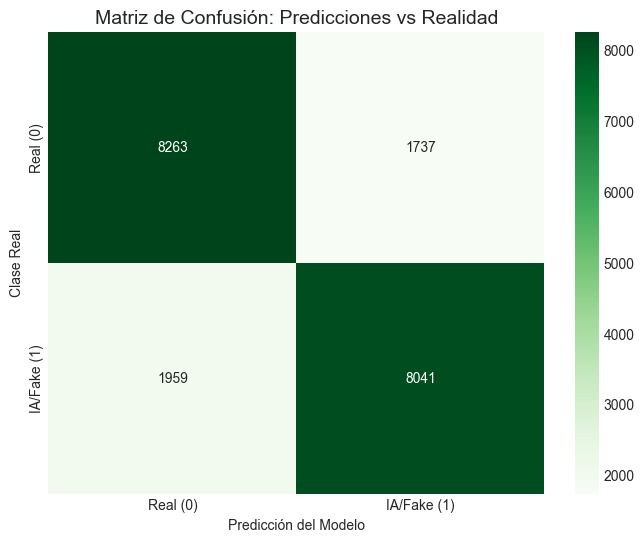

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Real (0)', 'IA/Fake (1)'], 
            yticklabels=['Real (0)', 'IA/Fake (1)'])
plt.title('Matriz de Confusión: Predicciones vs Realidad', fontsize=14)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.show()

C:\Users\vicen\AppData\Local\Temp\ipykernel_13868\2104154243.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia, y=features_nombres, palette='viridis')


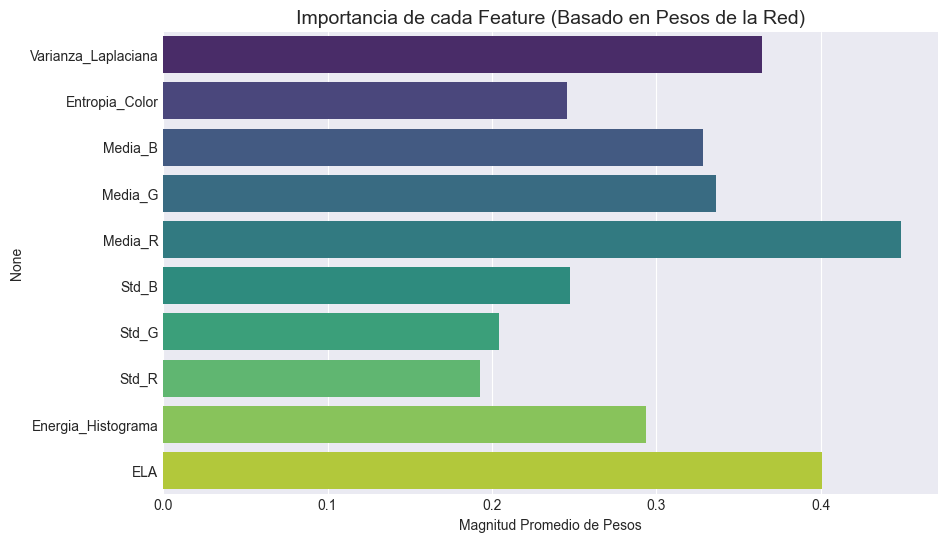

In [8]:
import numpy as np

# Importancia de las Características ---
# En un MLP, miramos la magnitud de los pesos de la primera capa
importancia = np.abs(mlp.coefs_[0]).mean(axis=1)
features_nombres = X_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importancia, y=features_nombres, palette='viridis')
plt.title('Importancia de cada Feature (Basado en Pesos de la Red)', fontsize=14)
plt.xlabel('Magnitud Promedio de Pesos')
plt.show()

In [9]:
import cv2
import numpy as np
from PIL import Image
import io

def extraer_caracteristicas(ruta_imagen):
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        return None
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    varianza_bordes = cv2.Laplacian(img_gray, cv2.CV_64F).var()

    entropias = []
    for canal in cv2.split(img_bgr):
        hist = cv2.calcHist([canal], [0], None, [256], [0, 256])
        hist = hist / hist.sum()
        hist = hist[hist > 0]
        entropias.append(-np.sum(hist * np.log2(hist)))
    entropia_color = np.mean(entropias)

    medias = [np.mean(c) for c in cv2.split(img_bgr)]
    stds = [np.std(c) for c in cv2.split(img_bgr)]

    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    hist = hist / hist.sum()
    energia = np.sum(hist**2)

    img_pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG", quality=90)
    buffer.seek(0)
    img_comprimida = Image.open(buffer)
    ela = np.abs(np.array(img_pil).astype(float) - np.array(img_comprimida).astype(float)).mean()

    return [varianza_bordes, entropia_color,
            medias[0], medias[1], medias[2],
            stds[0], stds[1], stds[2],
            energia, ela]

In [10]:
COLUMNAS_FEATURES = [
    'Varianza_Laplaciana', 'Entropia_Color',
    'Media_B', 'Media_G', 'Media_R',
    'Std_B', 'Std_G', 'Std_R',
    'Energia_Histograma', 'ELA'
]

def predecir_imagen(ruta_imagen, modelo, scaler):
    features = extraer_caracteristicas(ruta_imagen)
    if features is None:
        print("No se pudo leer la imagen")
        return
    X = pd.DataFrame([features], columns=COLUMNAS_FEATURES)
    X_scaled = scaler.transform(X)
    pred = modelo.predict(X_scaled)[0]
    proba = modelo.predict_proba(X_scaled)[0]
    clase = "Generada por IA" if pred == 1 else "Real"
    confianza = proba[pred] * 100
    print(f"Predicción: {clase} ({confianza:.1f}% de confianza)")

In [13]:
predecir_imagen("../dataset_raw/test/FAKE/2.jpg", mlp, scaler)

Predicción: Generada por IA (96.6% de confianza)


In [15]:
predecir_imagen("../dataset_raw/test/REAL/0002.jpg", mlp, scaler)

Predicción: Real (100.0% de confianza)


In [16]:
import numpy as np

mapeo = {0: "Real", 1: "Generada por IA"}
df_resultado = test_df.copy()
df_resultado["Salida Esperada"] = pd.Series(y_test.values).map(mapeo).values
df_resultado["Salida RNA"] = pd.Series(y_pred).map(mapeo).values
df_resultado["Acierto"] = np.where(y_test.values == y_pred, "SÍ", "NO")
df_resultado.to_csv("tabla_validacion.csv", index=False)
print("Guardada")

Guardada
